In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

loading Dataset

In [8]:
df=pd.read_csv(r'D:\pro_info\task2\data\Mall_Customers.csv')
print(df.head())

   CustomerID  Gender  Age  Annual_Income_(k$)  Spending_Score_(1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


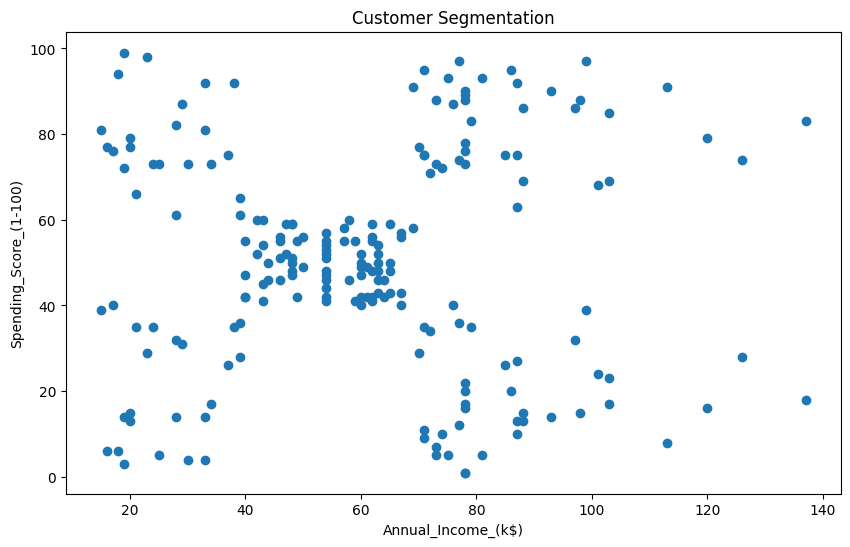

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(df['Annual_Income_(k$)'], df['Spending_Score_(1-100)'])
plt.xlabel('Annual_Income_(k$)')
plt.ylabel('Spending_Score_(1-100)')
plt.title('Customer Segmentation')
plt.show()

In [10]:
x=df.iloc[:, [3,4]].values
x[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

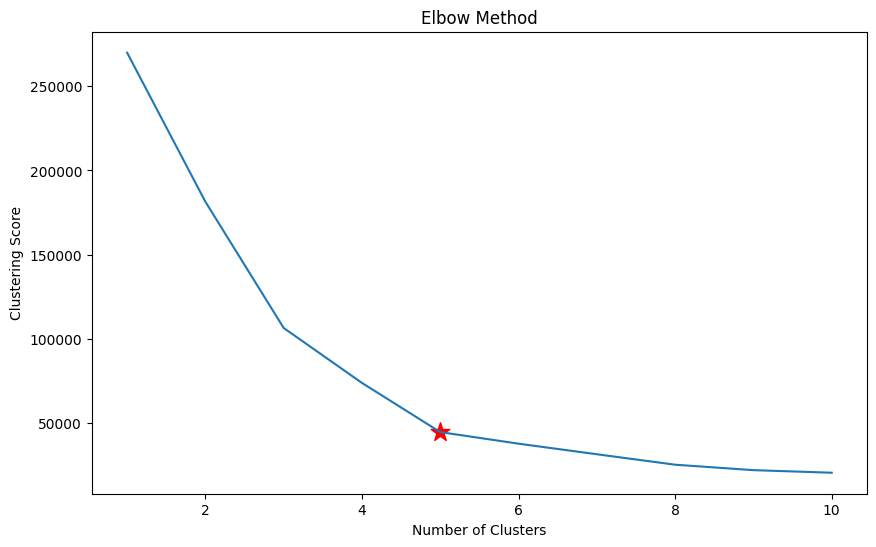

In [11]:
clustering_score=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i, init='random',random_state=42)
    kmeans.fit(x)
    clustering_score.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1,11), clustering_score)
plt.scatter(5,clustering_score[4],s=200,c='red',marker='*')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Clustering Score')
plt.show()

In [12]:
kmeans=KMeans(n_clusters=5,random_state=42)
kmeans.fit(x)
pred=kmeans.predict(x)
pred

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [13]:
df['Cluster']=pd.DataFrame(pred, columns=['cluster'])
print('no.of data points in each clusters=\n',df['Cluster'].value_counts())
df

no.of data points in each clusters=
 Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


,CustomerID,Gender,Age,Annual_Income_(k$),Spending_Score_(1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


Text(0.5, 1.0, 'Customer Segmentation')

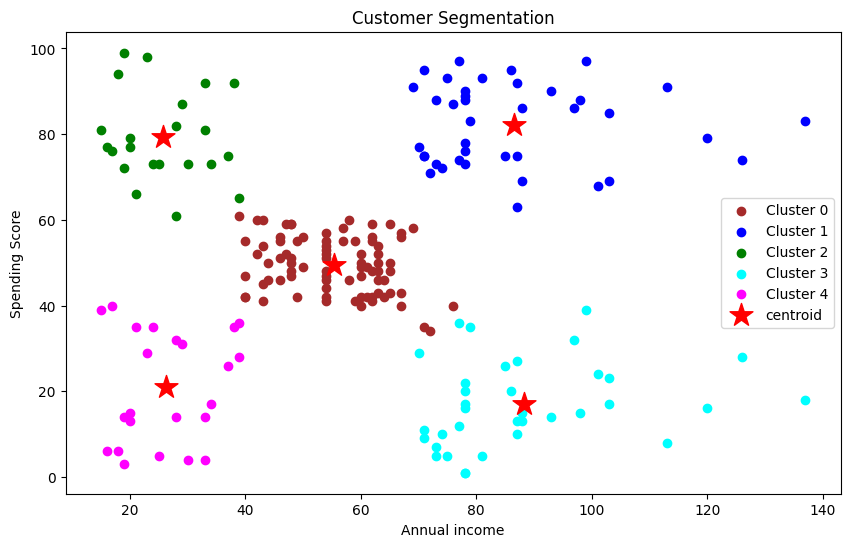

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(x[pred==0,0],x[pred==0,1],c='brown',label='Cluster 0')
plt.scatter(x[pred==1,0],x[pred==1,1],c='blue',label='Cluster 1')
plt.scatter(x[pred==2,0],x[pred==2,1],c='green',label='Cluster 2')
plt.scatter(x[pred==3,0],x[pred==3,1],c='cyan',label='Cluster 3')
plt.scatter(x[pred==4,0],x[pred==4,1],c='magenta',label='Cluster 4')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='red',label='centroid',marker='*')
plt.xlabel('Annual income')
plt.ylabel('Spending Score')
plt.legend()
plt.title('Customer Segmentation')

In [15]:
def plot_k_means_progress(centroid_history,n_clusters, centroid_sets, cluster_color):
     c_x = []
     c_y=[]
     for i in range(0, n_clusters):
        cluster_index = 0
        for j in range(0, centroid_sets):
            c_x = np.append(c_x, centroid_history[:,0][i + cluster_index])
            c_y = np.append(c_y, centroid_history[:,1][i + cluster_index])
            cluster_index = cluster_index + n_clusters
        plt.plot(c_x, c_y, c= cluster_color['c_' + str(i)], linestyle='--')
        c_x = []
        c_y = []   

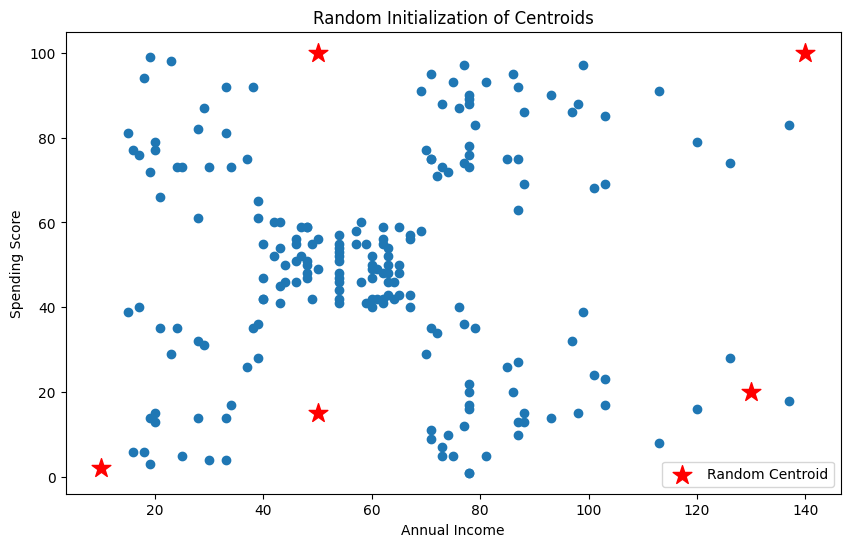

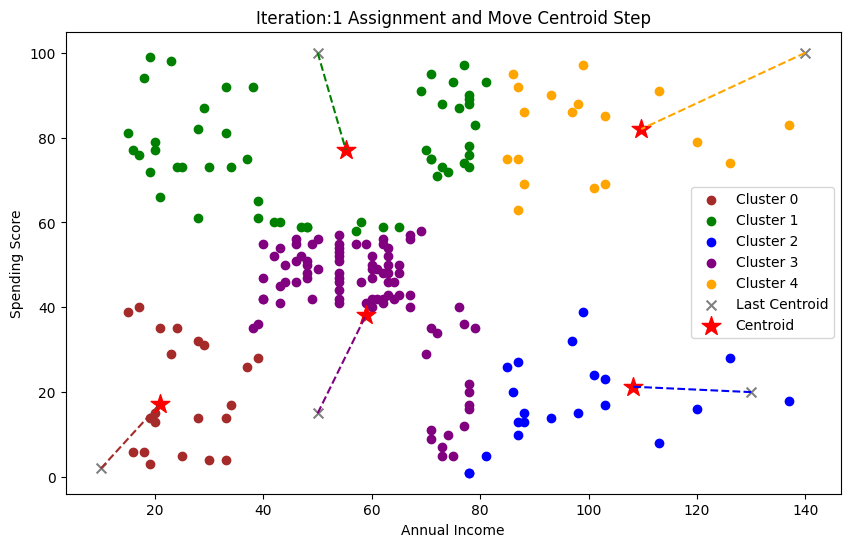

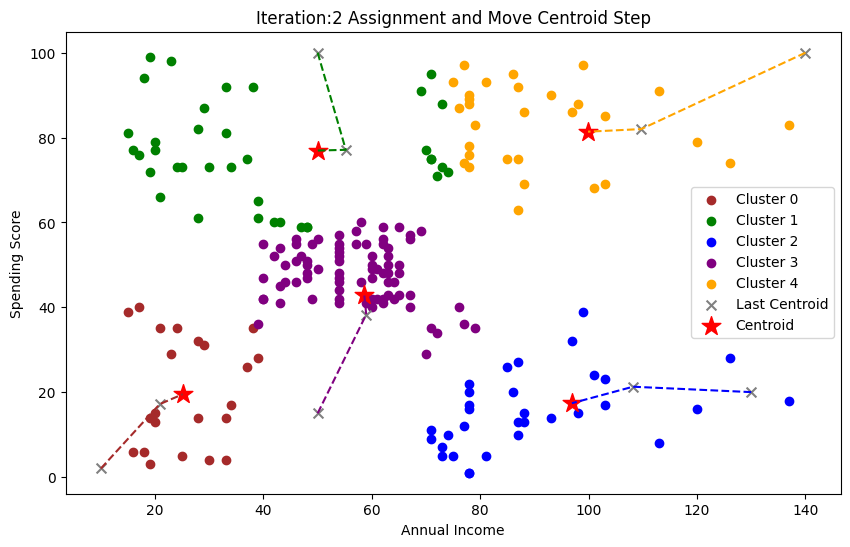

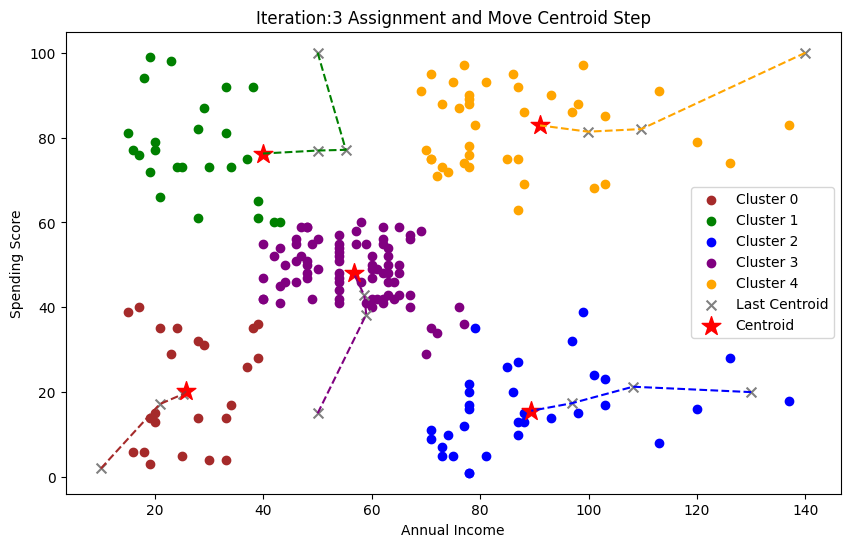

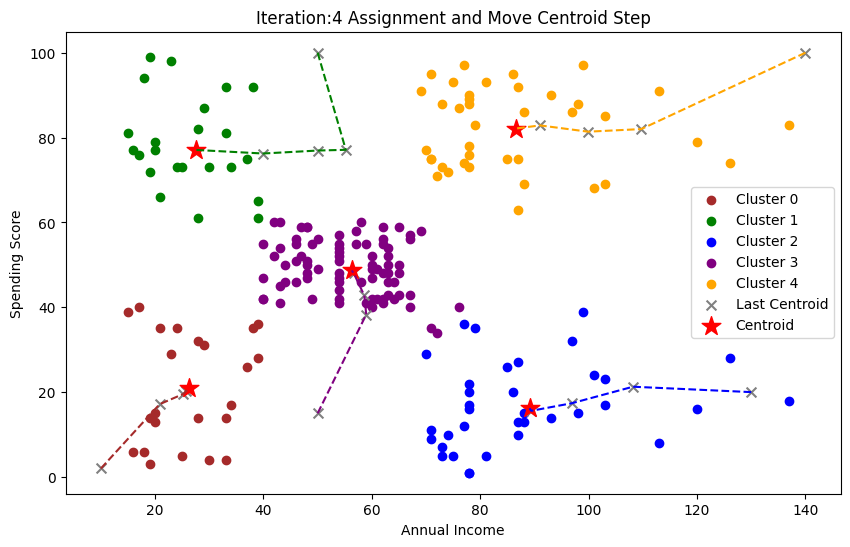

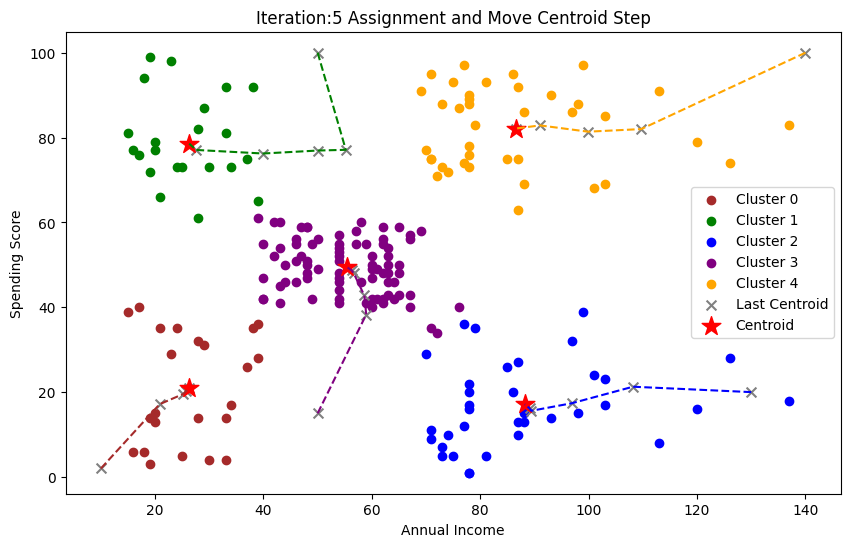

In [21]:
import numpy as np
plt.figure(figsize=(10,6))
plt.scatter(df['Annual_Income_(k$)'],df['Spending_Score_(1-100)'])
initial_centroid = np.array([[10, 2], [50,100], [130,20], [50,15], [140,100]])
plt.scatter(initial_centroid[:,0], initial_centroid[:, 1],s = 200, c = 'red', label = 'Random Centroid', marker='*')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.title('Random Initialization of Centroids')
centroid_history = []
centroid_history = initial_centroid
cluster_color= {'c_0':'brown','c_1':'green','c_2':'blue','c_3':'purple','c_4':'orange'}
n_clusters = 5
for i in range(1,6):
    kmeans= KMeans(n_clusters, init= initial_centroid, n_init= 1, max_iter= i, random_state = 42)
    pred = kmeans.fit_predict(x)
    plt.figure(figsize=(10,6))
    plt.scatter(x[pred == 0, 0], x[pred == 0, 1], c = 'brown', label = 'Cluster 0')
    plt.scatter(x[pred == 1, 0], x[pred == 1, 1], c = 'green', label = 'Cluster 1')
    plt.scatter(x[pred == 2, 0], x[pred == 2, 1], c = 'blue', label = 'Cluster 2')
    plt.scatter(x[pred == 3, 0], x[pred == 3, 1], c = 'purple', label = 'Cluster 3')
    plt.scatter(x[pred == 4, 0], x[pred == 4, 1], c = 'orange', label = 'Cluster 4') 
    
    plt.scatter(centroid_history[:,0], centroid_history[:, 1],s = 50, c = 'gray', label = 'Last Centroid', marker='x')
    
    plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:, 1],s = 200, c = 'red', label = 'Centroid', marker='*')
    
    centroid_history = np.append(centroid_history, kmeans.cluster_centers_, axis=0)
    
    plt.xlabel('Annual Income')
    plt.ylabel('Spending Score')
    plt.legend()
    plt.title('Iteration:' + str(i) + ' Assignment and Move Centroid Step')
    
    centroid_sets = i + 1 
    plot_k_means_progress(centroid_history,n_clusters, centroid_sets, cluster_color)